<a href="https://colab.research.google.com/github/Raksh1707/Naturalproject/blob/main/nlp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [209]:
import pandas as pd
import random
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)



In [191]:
spam_emails = [
    "Exclusive Deal! Get 70% OFF on all electronics. Shop today!",
    "Congratulations! You have been selected to receive a cash reward.",
    "Claim your free vacation package before midnight.",
    "Limited-time offer! Buy one, get three absolutely free.",
    "Your account has won a lucky draw prize. Verify now.",
    "Earn ₹10,000 every week from home. No experience required.",
    "Final reminder! Your reward points will expire today.",
    "Congratulations! Spin the wheel and win exciting prizes.",
    "Special promotion! Upgrade today and save 80%.",
    "You have been pre-approved for a premium credit card.",
    "Win the latest smartphone by completing a quick survey.",
    "Hurry! This amazing deal ends within the next hour."
]

ham_emails = [
    "Good morning, the team meeting is scheduled for 11:00 AM tomorrow.",
    "Please submit your assignment before Friday evening.",
    "Your interview has been confirmed for next Monday.",
    "The monthly project review has been postponed to Wednesday.",
    "Kindly review the attached document and share your comments.",
    "Your library books are due for return this weekend.",
    "Thank you for attending today's training session.",
    "Let's schedule a discussion regarding the new software module.",
    "Your attendance record has been updated successfully.",
    "Please join the online class using the shared meeting link.",
    "We have received your leave application and it has been approved.",
    "Please contact the administration office if you have any questions."
]

In [192]:
random.seed(42)

data = []

for i in range(1000):

    # 50% spam and 50% ham
    if i < 500:

        # 85% correct spam emails
        if random.random() < 0.85:
            email = random.choice(spam_emails)
        else:
            # 15% confusing normal-looking emails
            email = random.choice(ham_emails)

        label = "spam"

    else:

        # 85% correct ham emails
        if random.random() < 0.85:
            email = random.choice(ham_emails)
        else:

            email = random.choice(spam_emails)

        label = "ham"

    data.append([email, label])




In [193]:
df = pd.DataFrame(
    data,
    columns=["Email", "Label"]
)


df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.head(10)



,Email,Label
0,Thank you for attending today's training session.,ham
1,Your attendance record has been updated succes...,ham
2,Thank you for attending today's training session.,ham
3,Claim your free vacation package before midnight.,ham
4,Win the latest smartphone by completing a quic...,spam
5,The office will remain closed on the upcoming ...,ham
6,The office will remain closed on the upcoming ...,ham
7,Let's schedule a discussion regarding the new ...,ham
8,The monthly project review has been postponed ...,ham
9,We have received your leave application and it...,spam


In [194]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 2)


In [195]:
df["Label"].value_counts()

,count
Label,
ham,500
spam,500


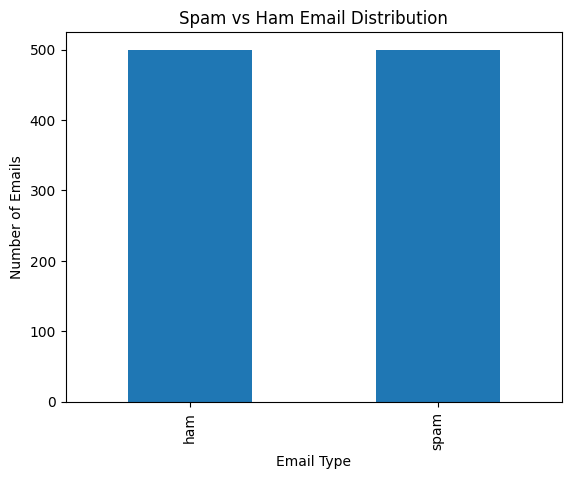

In [196]:
df["Label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Email Distribution")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.show()

In [197]:
df.isnull().sum()

,0
Email,0
Label,0


In [198]:
df.duplicated().sum()

np.int64(944)

In [199]:
df["Clean_Email"] = df["Email"].apply(clean_text)

df.head(10)

,Email,Label,Clean_Email
0,Thank you for attending today's training session.,ham,thank you for attending todays training session
1,Your attendance record has been updated succes...,ham,your attendance record has been updated succes...
2,Thank you for attending today's training session.,ham,thank you for attending todays training session
3,Claim your free vacation package before midnight.,ham,claim your free vacation package before midnight
4,Win the latest smartphone by completing a quic...,spam,win the latest smartphone by completing a quic...
5,The office will remain closed on the upcoming ...,ham,the office will remain closed on the upcoming ...
6,The office will remain closed on the upcoming ...,ham,the office will remain closed on the upcoming ...
7,Let's schedule a discussion regarding the new ...,ham,lets schedule a discussion regarding the new s...
8,The monthly project review has been postponed ...,ham,the monthly project review has been postponed ...
9,We have received your leave application and it...,spam,we have received your leave application and it...


In [200]:
for i in range(5):

    print("Original Email:")
    print(df["Email"].iloc[i])

    print("\nCleaned Email:")
    print(df["Clean_Email"].iloc[i])

    print("-" * 70)

Original Email:
Thank you for attending today's training session.

Cleaned Email:
thank you for attending todays training session
----------------------------------------------------------------------
Original Email:
Your attendance record has been updated successfully.

Cleaned Email:
your attendance record has been updated successfully
----------------------------------------------------------------------
Original Email:
Thank you for attending today's training session.

Cleaned Email:
thank you for attending todays training session
----------------------------------------------------------------------
Original Email:
Claim your free vacation package before midnight.

Cleaned Email:
claim your free vacation package before midnight
----------------------------------------------------------------------
Original Email:
Win the latest smartphone by completing a quick survey.

Cleaned Email:
win the latest smartphone by completing a quick survey
-------------------------------------------

In [201]:
X = df["Clean_Email"]
y = df["Label"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training Emails:", len(X_train))
print("Testing Emails :", len(X_test))


Training Emails: 800
Testing Emails : 200


In [202]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.875


Confusion Matrix:
[[89 11]
 [14 86]]


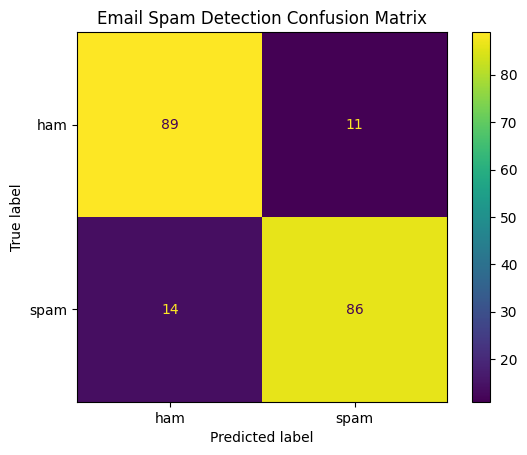

In [203]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")

print(cm)


ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
).plot()

plt.title("Email Spam Detection Confusion Matrix")

plt.show()

In [204]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

         ham       0.86      0.89      0.88       100
        spam       0.89      0.86      0.87       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.87       200



In [205]:

total_emails = len(df)
total_spam = (df["Label"] == "spam").sum()
total_ham = (df["Label"] == "ham").sum()

print("========== SPAM ANALYSIS REPORT ==========")

print("Total Emails :", total_emails)
print("Spam Emails  :", total_spam)
print("Ham Emails   :", total_ham)

print("Spam % :", round((total_spam / total_emails) * 100, 2))
print("Ham %  :", round((total_ham / total_emails) * 100, 2))

print("Model Accuracy :", round(accuracy * 100, 2), "%")

if accuracy >= 0.90:
    print("Result : Excellent Spam Detection")
elif accuracy >= 0.80:
    print("Result : Good Spam Detection")
else:
    print("Result : Needs Improvement")

========== SPAM ANALYSIS REPORT ==========
Total Emails : 1000
Spam Emails  : 500
Ham Emails   : 500
Spam % : 50.0
Ham %  : 50.0
Model Accuracy : 85.0 %
Result : Good Spam Detection


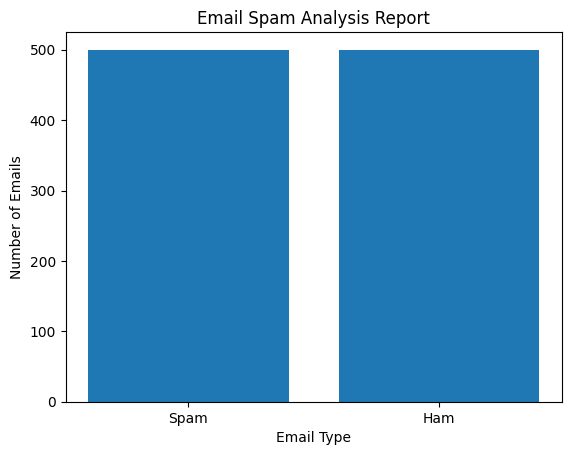

In [206]:
report_data = pd.DataFrame({
    "Email Type": ["Spam", "Ham"],
    "Count": [total_spam, total_ham]
})

plt.bar(
    report_data["Email Type"],
    report_data["Count"]
)

plt.title("Email Spam Analysis Report")

plt.xlabel("Email Type")

plt.ylabel("Number of Emails")

plt.show()

In [207]:
def predict_email(email):


    cleaned_email = clean_text(email)
    email_tfidf = tfidf.transform(
        [cleaned_email]
    )


    prediction = model.predict(
        email_tfidf
    )[0]

    return prediction


new_email = """
CONGRATULATIONS!!!
You WON $100,0000!!!
Click NOW!!!
"""

prediction = predict_email(new_email)

print("Email      :", new_email)

print("Prediction :", prediction)


Email      : 
CONGRATULATIONS!!!
You WON $100,0000!!!
Click NOW!!!

Prediction : spam


In [210]:
new_email = """
Hi raksha,
Congratulations! You have been selected to receive a cash reward
"""

prediction = predict_email(new_email)

print("Email      :", new_email)

print("Prediction :", prediction)

Email      : 
Hi raksha,
Congratulations! You have been selected to receive a cash reward

Prediction : spam
